---

# $k$-Means Clustering

Here we focus on **$k$-Means Clustering**, one of the most widely used clustering algorithms. We apply it to the Wine dataset (13 chemical features, 178 samples, 3 true cultivar classes) and build the entire algorithm from scratch before comparing with `sklearn`.

---

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()
plt.rcParams["figure.figsize"] = (10, 8)

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

---

## 2. Load the Wine Dataset

The Wine dataset contains **178 samples** described by **13 chemical features** belonging to one of **3 cultivar classes**. Because $k$-means is *unsupervised*, we load the labels only to evaluate the quality of the discovered clusters after the fact — they play no role during training.

---

In [2]:
data = load_wine()

X_df = pd.DataFrame(data.data, columns=data.feature_names)
y_true = data.target          # kept aside — NOT used during clustering

target_names  = list(data.target_names)
class_mapping = {i: name for i, name in enumerate(target_names)}

print("Feature matrix shape:", X_df.shape)
print("True classes        :", target_names)
print("\nClass distribution:")
print(pd.Series(y_true).value_counts().rename(index=class_mapping))

X_df.head()

Feature matrix shape: (178, 13)
True classes        : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Class distribution:
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
X_df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


---

## 3. Standardise the Features

$k$-Means relies on **Euclidean distance**. Features with large numerical ranges (e.g. proline: 278–1680) will dominate the distance calculation and drown out features on smaller scales. We therefore standardise every feature to zero mean and unit variance before clustering.

---

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(X_df.to_numpy())

print("Post-scaling mean (should ≈ 0):", X.mean(axis=0).round(6))
print("Post-scaling std  (should ≈ 1):", X.std(axis=0).round(6))

Post-scaling mean (should ≈ 0): [-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]
Post-scaling std  (should ≈ 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---

## 4. Exploratory Visualisation (PCA Projection)

Our data lives in $\mathbb{R}^{13}$, which we cannot directly plot. We use **Principal Component Analysis (PCA)** to project onto the first two principal components for visualisation. This 2D projection is used *only* for plotting — all clustering is done in the full 13-dimensional space.

---

In [5]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance captured  : {pca.explained_variance_ratio_.sum():.2%}")

Variance explained by PC1: 36.20%
Variance explained by PC2: 19.21%
Total variance captured  : 55.41%


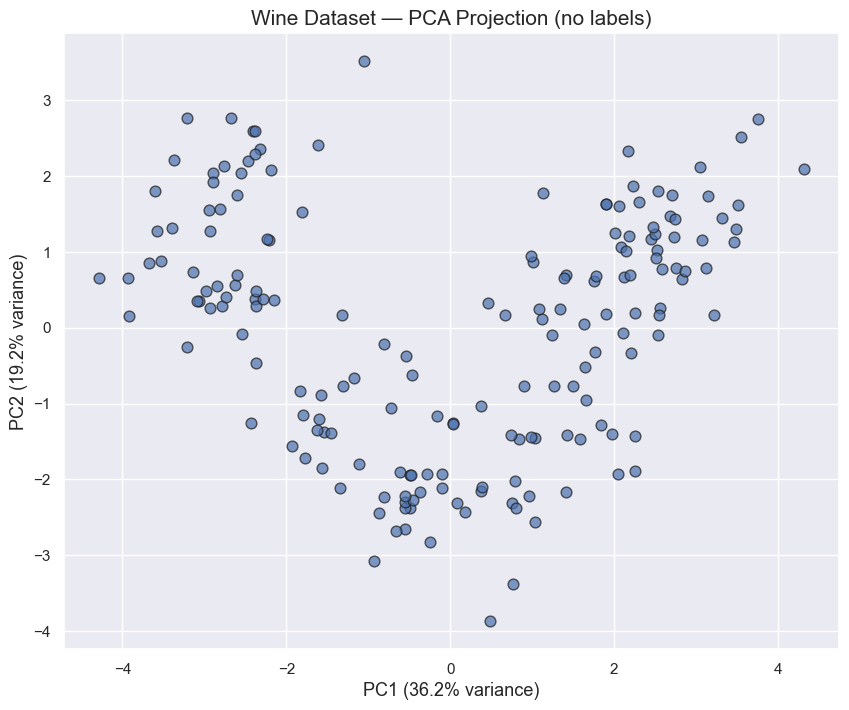

In [6]:
def cluster_colors(label):
    """Map cluster index to a consistent colour."""
    palette = ["red", "lightseagreen", "magenta", "blue", "gold"]
    return palette[label % len(palette)]

# Plot the raw data with no labels (as the algorithm sees it)
plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.7, edgecolors="k", s=60)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=13)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=13)
plt.title("Wine Dataset — PCA Projection (no labels)", fontsize=15)
plt.show()

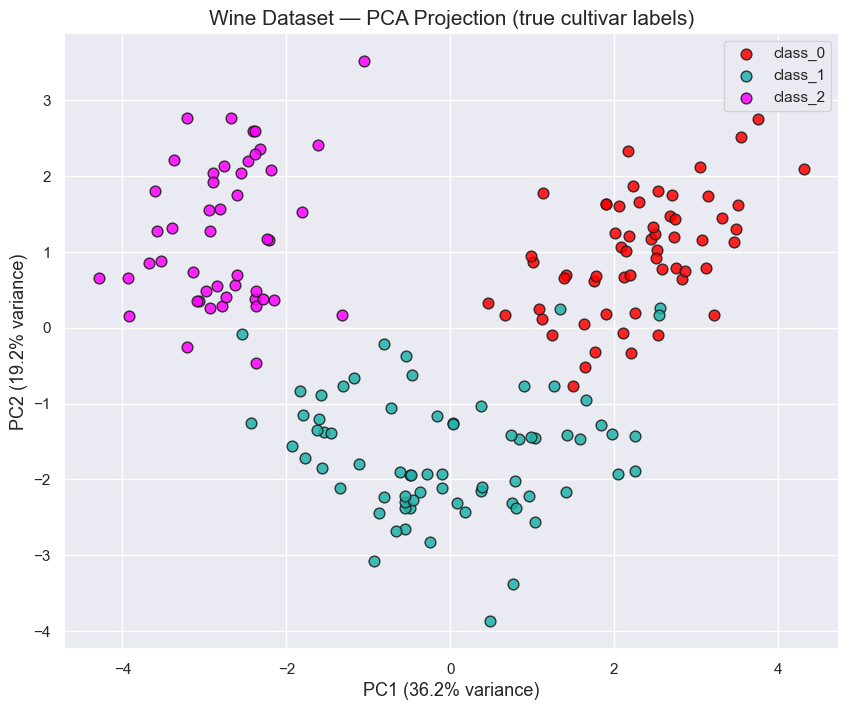

In [7]:
# Plot with true labels (for reference only)
true_colors = [cluster_colors(label) for label in y_true]

plt.figure(figsize=(10, 8))
for cls in range(3):
    mask = y_true == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                color=cluster_colors(cls), label=target_names[cls],
                edgecolors="k", s=60, alpha=0.85)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=13)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=13)
plt.title("Wine Dataset — PCA Projection (true cultivar labels)", fontsize=15)
plt.legend(fontsize=11)
plt.show()

---

## 5. $k$-Means Algorithm — Built from Scratch

### How it works

1. **Initialise** $k$ cluster centres by randomly selecting $k$ data points.
2. **Assign** each point to the nearest centre (by Euclidean distance).
3. **Update** each centre to the mean of all points currently assigned to it.
4. **Repeat** steps 2–3 until convergence (or for a fixed number of iterations).

We implement each step as a standalone function, exactly as in the lecture.

---

In [8]:
def distance(i, X, center):
    """Euclidean distance from row i of X to a centre point."""
    return np.sqrt(sum((X[i, j] - center[j])**2 for j in range(X.shape[1])))

# Quick sanity check
test_center = X[0]
print(f"Distance from sample 0 to itself  : {distance(0, X, test_center):.4f}")
print(f"Distance from sample 1 to sample 0: {distance(1, X, test_center):.4f}")

Distance from sample 0 to itself  : 0.0000
Distance from sample 1 to sample 0: 3.4975


In [9]:
def assign_label(i, X, centers):
    """Return the index of the nearest centre to row i of X."""
    distances = np.array([distance(i, X, center) for center in centers])
    return np.argmin(distances)

def assign_clusters(X, centers):
    """Assign every row of X to its nearest centre."""
    return [assign_label(i, X, centers) for i in range(len(X))]

print("assign_label and assign_clusters defined.")

assign_label and assign_clusters defined.


In [10]:
def update_centers(X, centers):
    """
    Recompute each centre as the mean of all points currently
    assigned to it.
    """
    current_labels = assign_clusters(X, centers)
    k = len(centers)
    p = X.shape[1]

    # Accumulate sums and counts per cluster
    sums   = {i: np.zeros(p) for i in range(k)}
    counts = {i: 0           for i in range(k)}

    for i, label in enumerate(current_labels):
        sums[label]   += X[i]
        counts[label] += 1

    # New centres = mean of assigned points
    new_centers = [sums[i] / counts[i] for i in range(k)]
    return new_centers

print("update_centers defined.")

update_centers defined.


In [11]:
def k_means_clustering(X, k, max_iter=100, random_state=42):
    """
    Full k-Means algorithm from scratch.
    Returns the final list of k centre vectors.
    """
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=k, replace=False)
    centers = [X[i] for i in indices]

    for _ in range(max_iter):
        centers = update_centers(X, centers)

    return centers

print("k_means_clustering defined.")

k_means_clustering defined.


---

## 6. Step-by-Step Visualisation of Convergence

Before running the full algorithm, we visualise how the cluster assignments evolve iteration by iteration, starting from random initialisation.

---

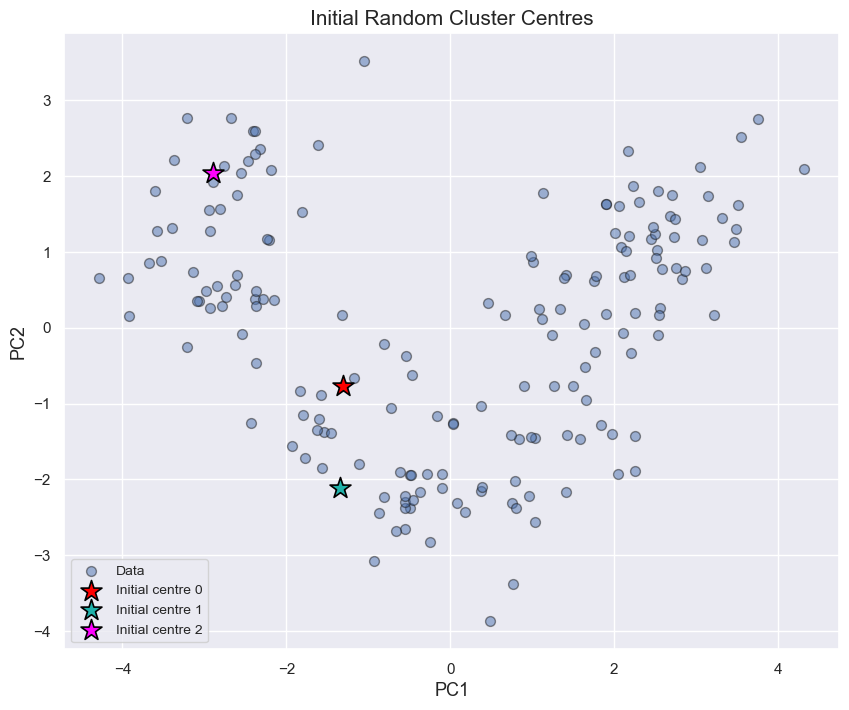

In [12]:
# Initialise 3 random centres
np.random.seed(0)
rng = np.random.default_rng(0)
init_indices = rng.choice(len(X), size=3, replace=False)
centers = [X[i] for i in init_indices]

# Plot initial random centres over unlabelled data (PCA projection for viz)
centers_2d = pca.transform(np.array(centers))

plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, edgecolors="k", s=50, label="Data")
for j, (cx, cy) in enumerate(centers_2d):
    plt.scatter(cx, cy, color=cluster_colors(j),
                s=250, marker="*", edgecolors="black", linewidths=1.2,
                label=f"Initial centre {j}")
plt.title("Initial Random Cluster Centres", fontsize=15)
plt.legend(fontsize=10)
plt.xlabel("PC1", fontsize=13); plt.ylabel("PC2", fontsize=13)
plt.show()

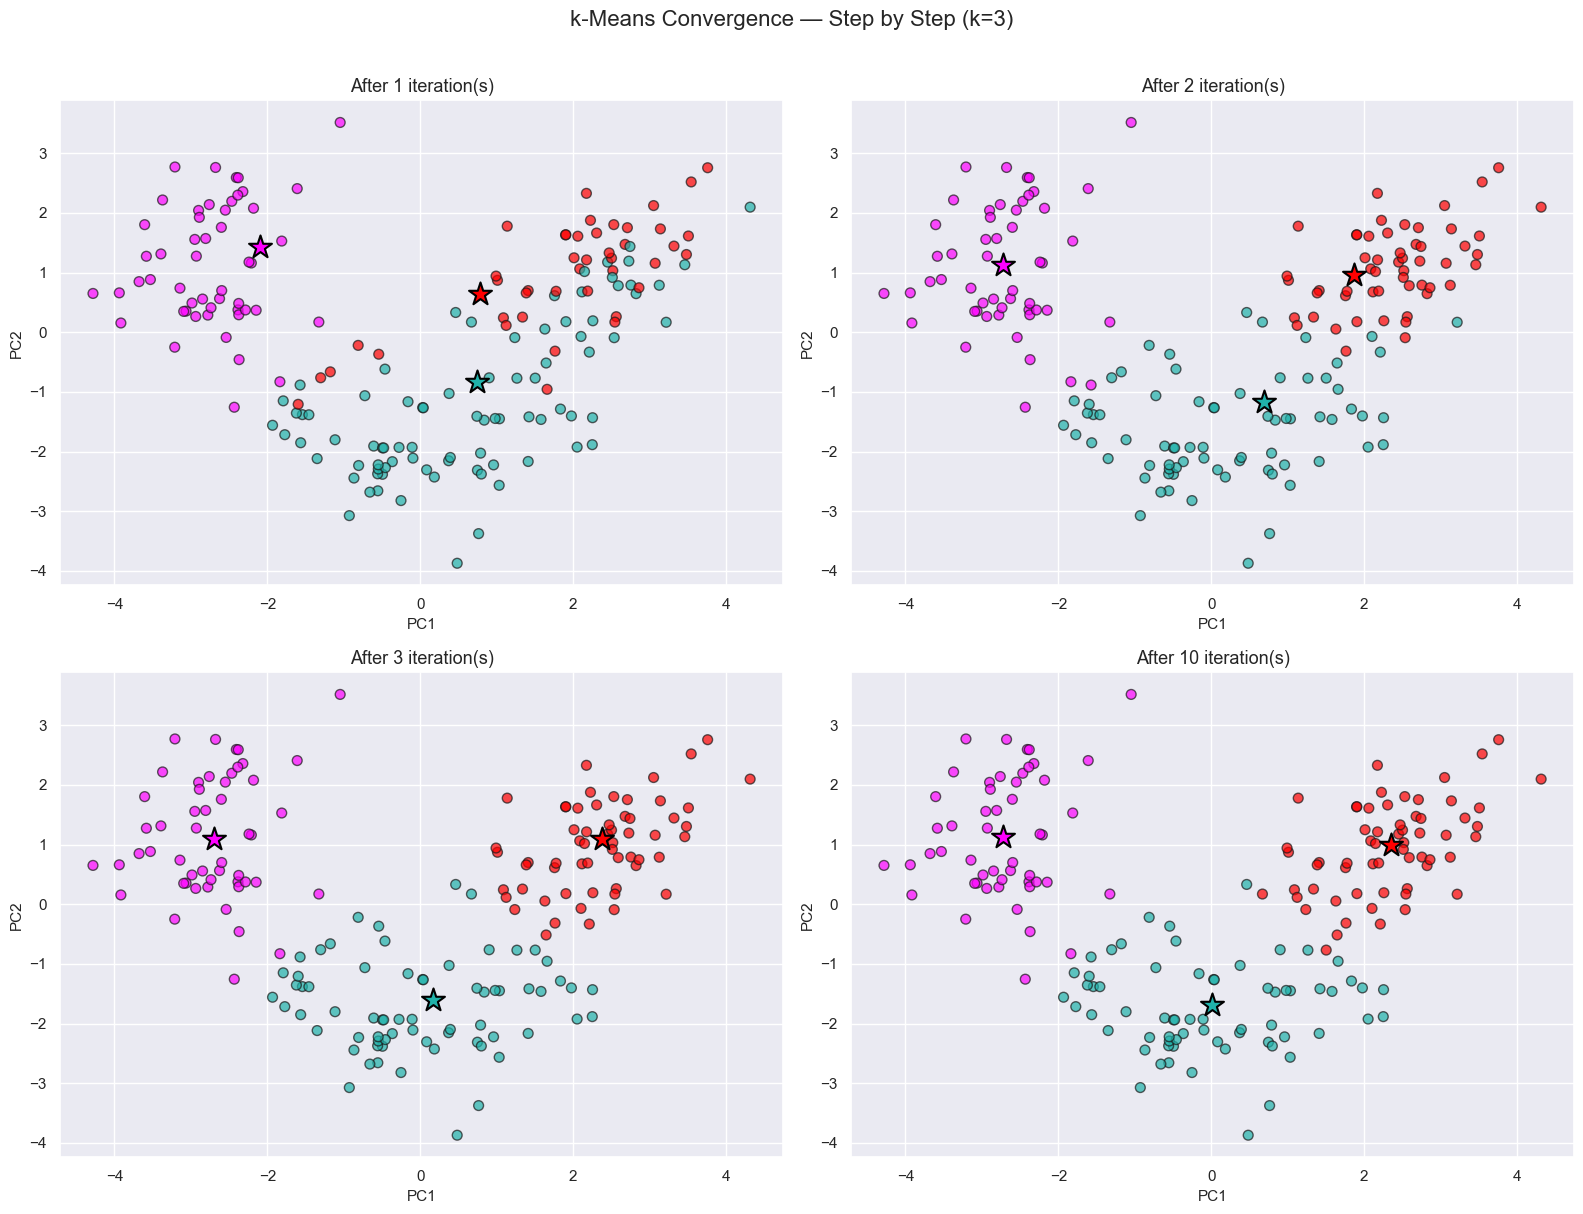

In [13]:
# Show cluster assignments after iterations 1, 2, 3, and 10
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
iter_steps = [1, 2, 3, 10]
current_centers = [X[i] for i in init_indices]  # reset

for ax, step in zip(axes.flatten(), iter_steps):
    for _ in range(step if step == 1 else 1):
        current_centers = update_centers(X, current_centers)

    labels = assign_clusters(X, current_centers)
    c_plot = [cluster_colors(l) for l in labels]
    centers_2d_step = pca.transform(np.array(current_centers))

    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=c_plot, alpha=0.7,
               edgecolors="k", s=50)
    for j, (cx, cy) in enumerate(centers_2d_step):
        ax.scatter(cx, cy, color=cluster_colors(j),
                   s=300, marker="*", edgecolors="black", linewidths=1.5)
    ax.set_title(f"After {step} iteration(s)", fontsize=13)
    ax.set_xlabel("PC1", fontsize=11)
    ax.set_ylabel("PC2", fontsize=11)

plt.suptitle("k-Means Convergence — Step by Step (k=3)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---

## 7. Run Full $k$-Means (k = 3)

Now we run the complete algorithm for 100 iterations and visualise the final clusters alongside the true cultivar labels.

---

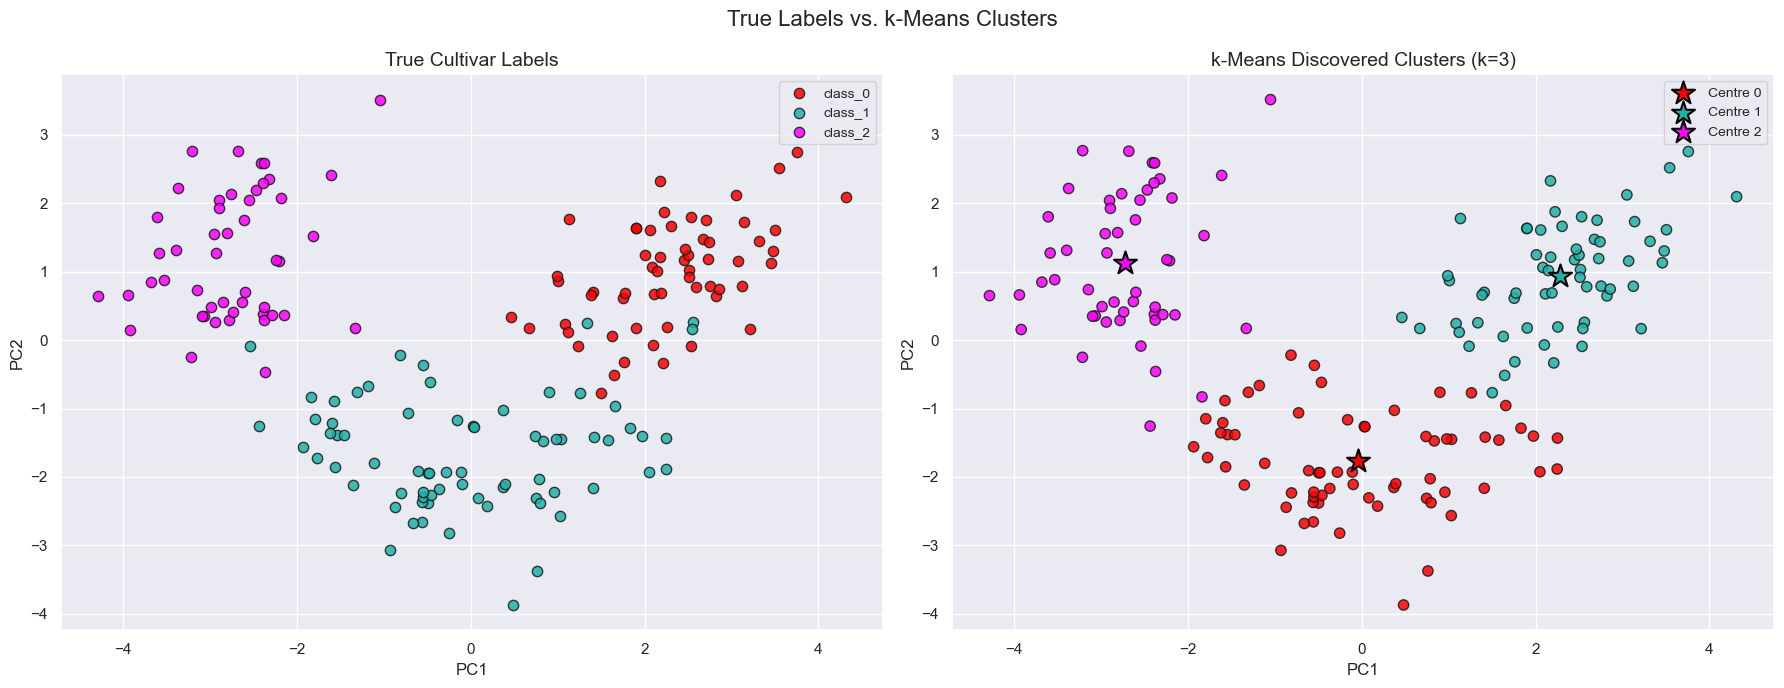

In [14]:
# Run from-scratch k-means with k=3
final_centers = k_means_clustering(X, k=3, max_iter=100, random_state=42)
final_labels  = assign_clusters(X, final_centers)
final_colors  = [cluster_colors(l) for l in final_labels]
centers_2d_final = pca.transform(np.array(final_centers))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# True labels
for cls in range(3):
    mask = y_true == cls
    ax1.scatter(X_2d[mask, 0], X_2d[mask, 1],
                color=cluster_colors(cls), label=target_names[cls],
                edgecolors="k", s=55, alpha=0.85)
ax1.set_title("True Cultivar Labels", fontsize=14)
ax1.set_xlabel("PC1", fontsize=12); ax1.set_ylabel("PC2", fontsize=12)
ax1.legend(fontsize=10)

# k-Means discovered clusters
ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=final_colors,
            edgecolors="k", s=55, alpha=0.85)
for j, (cx, cy) in enumerate(centers_2d_final):
    ax2.scatter(cx, cy, color=cluster_colors(j),
                s=300, marker="*", edgecolors="black", linewidths=1.5,
                label=f"Centre {j}")
ax2.set_title("k-Means Discovered Clusters (k=3)", fontsize=14)
ax2.set_xlabel("PC1", fontsize=12); ax2.set_ylabel("PC2", fontsize=12)
ax2.legend(fontsize=10)

plt.suptitle("True Labels vs. k-Means Clusters", fontsize=16)
plt.tight_layout()
plt.show()

---

## 8. Evaluate Cluster Quality

Because we withheld the true labels, we can now use them as a **reference** to evaluate how well our algorithm recovered the natural groupings. We use two metrics:

- **Adjusted Rand Index (ARI)** — measures overlap between discovered clusters and true labels; 1.0 = perfect, 0 = random.
- **Silhouette Score** — measures how similar each point is to its own cluster vs. neighbouring clusters; ranges from −1 to 1; higher is better. This metric requires *no* ground truth.

---

In [15]:
ari       = adjusted_rand_score(y_true, final_labels)
sil_score = silhouette_score(X, final_labels)

print(f"Adjusted Rand Index (ARI) : {ari:.4f}")
print(f"Silhouette Score          : {sil_score:.4f}")

Adjusted Rand Index (ARI) : 0.8975
Silhouette Score          : 0.2849


---

## 9. Choosing $k$ — The Elbow Method

In a real unsupervised setting we do not know the true number of clusters in advance. The **Elbow Method** plots the **Within-Cluster Sum of Squares (WCSS)** — also called inertia — for a range of $k$ values and looks for an "elbow" where the rate of decrease slows down sharply.

$$\text{WCSS}(k) = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

---

In [16]:
def wcss(X, centers):
    """Within-Cluster Sum of Squares for a given set of centres."""
    labels = assign_clusters(X, centers)
    total  = 0.0
    for i, label in enumerate(labels):
        total += distance(i, X, centers[label]) ** 2
    return total

k_range  = range(1, 11)
wcss_vals = []
ari_vals  = []
sil_vals  = []

for k in k_range:
    centers_k = k_means_clustering(X, k=k, max_iter=100, random_state=42)
    labels_k  = assign_clusters(X, centers_k)
    wcss_vals.append(wcss(X, centers_k))
    ari_vals.append(adjusted_rand_score(y_true, labels_k))
    if k > 1:   # silhouette undefined for k=1
        sil_vals.append(silhouette_score(X, labels_k))
    else:
        sil_vals.append(np.nan)

print(f"{'k':>3} | {'WCSS':>10} | {'ARI':>8} | {'Silhouette':>10}")
print("-" * 38)
for k, w, a, s in zip(k_range, wcss_vals, ari_vals, sil_vals):
    s_str = f"{s:.4f}" if not np.isnan(s) else "   N/A"
    print(f"{k:>3} | {w:>10.2f} | {a:>8.4f} | {s_str:>10}")

  k |       WCSS |      ARI | Silhouette
--------------------------------------
  1 |    2314.00 |   0.0000 |        N/A
  2 |    1659.01 |   0.3887 |     0.2683
  3 |    1277.93 |   0.8975 |     0.2849
  4 |    1205.61 |   0.8009 |     0.2698
  5 |    1128.72 |   0.6303 |     0.1872
  6 |    1069.76 |   0.6022 |     0.1943
  7 |    1042.92 |   0.5652 |     0.1931
  8 |     997.39 |   0.5040 |     0.1742
  9 |     932.87 |   0.3694 |     0.1384
 10 |     900.63 |   0.3867 |     0.1258


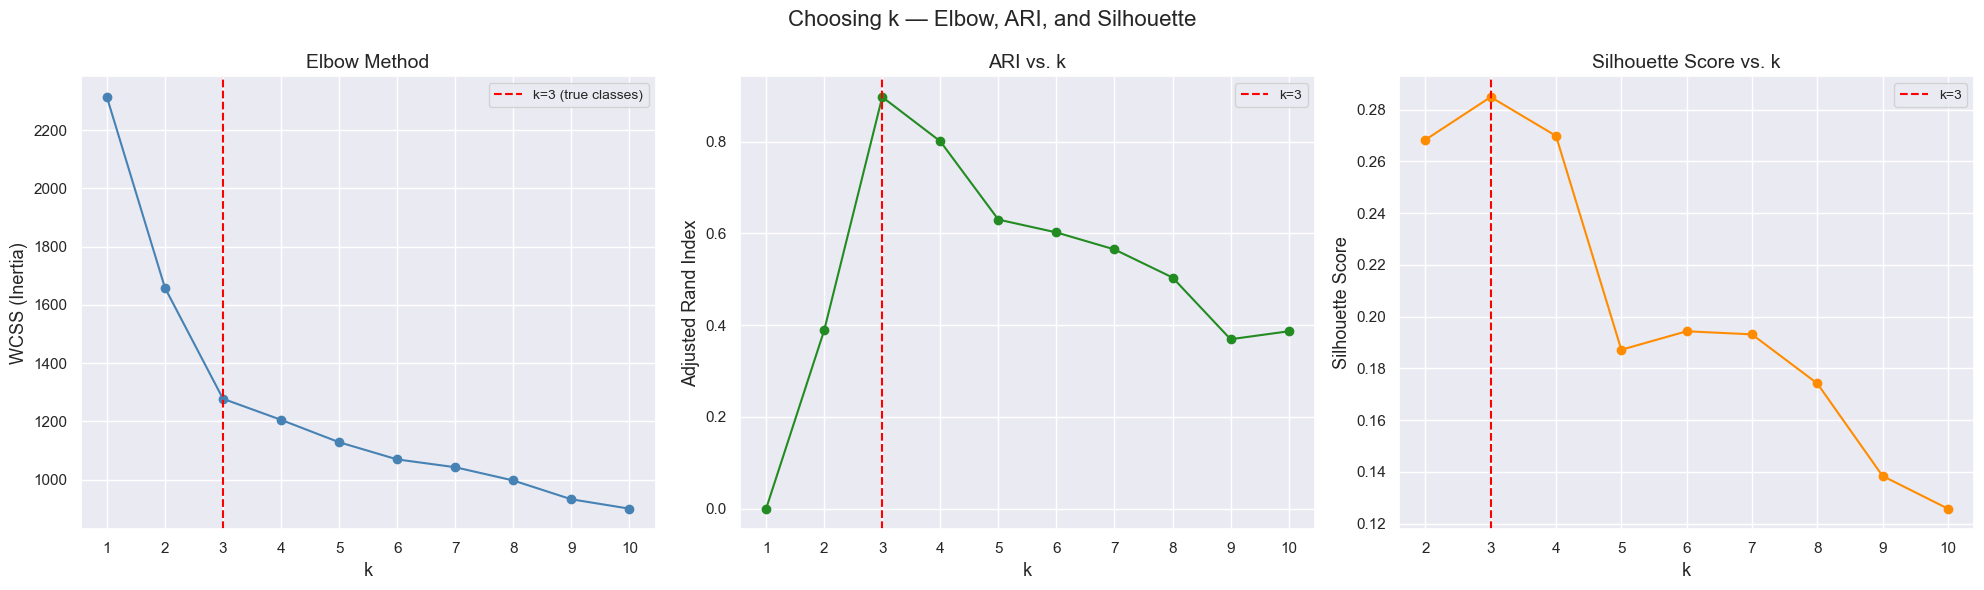

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Elbow curve
axes[0].plot(list(k_range), wcss_vals, marker="o", color="steelblue")
axes[0].axvline(x=3, linestyle="--", color="red", label="k=3 (true classes)")
axes[0].set_xlabel("k", fontsize=13)
axes[0].set_ylabel("WCSS (Inertia)", fontsize=13)
axes[0].set_title("Elbow Method", fontsize=14)
axes[0].set_xticks(list(k_range))
axes[0].legend(fontsize=10)

# ARI vs k
axes[1].plot(list(k_range), ari_vals, marker="o", color="forestgreen")
axes[1].axvline(x=3, linestyle="--", color="red", label="k=3")
axes[1].set_xlabel("k", fontsize=13)
axes[1].set_ylabel("Adjusted Rand Index", fontsize=13)
axes[1].set_title("ARI vs. k", fontsize=14)
axes[1].set_xticks(list(k_range))
axes[1].legend(fontsize=10)

# Silhouette vs k
axes[2].plot(list(k_range)[1:], sil_vals[1:], marker="o", color="darkorange")
axes[2].axvline(x=3, linestyle="--", color="red", label="k=3")
axes[2].set_xlabel("k", fontsize=13)
axes[2].set_ylabel("Silhouette Score", fontsize=13)
axes[2].set_title("Silhouette Score vs. k", fontsize=14)
axes[2].set_xticks(list(k_range)[1:])
axes[2].legend(fontsize=10)

plt.suptitle("Choosing k — Elbow, ARI, and Silhouette", fontsize=16)
plt.tight_layout()
plt.show()

---

## 10. Effect of $k$ on Cluster Assignments

We visualise the PCA projection for $k = 2, 3, 4, 5$ side-by-side to see how increasing $k$ changes the discovered structure.

---

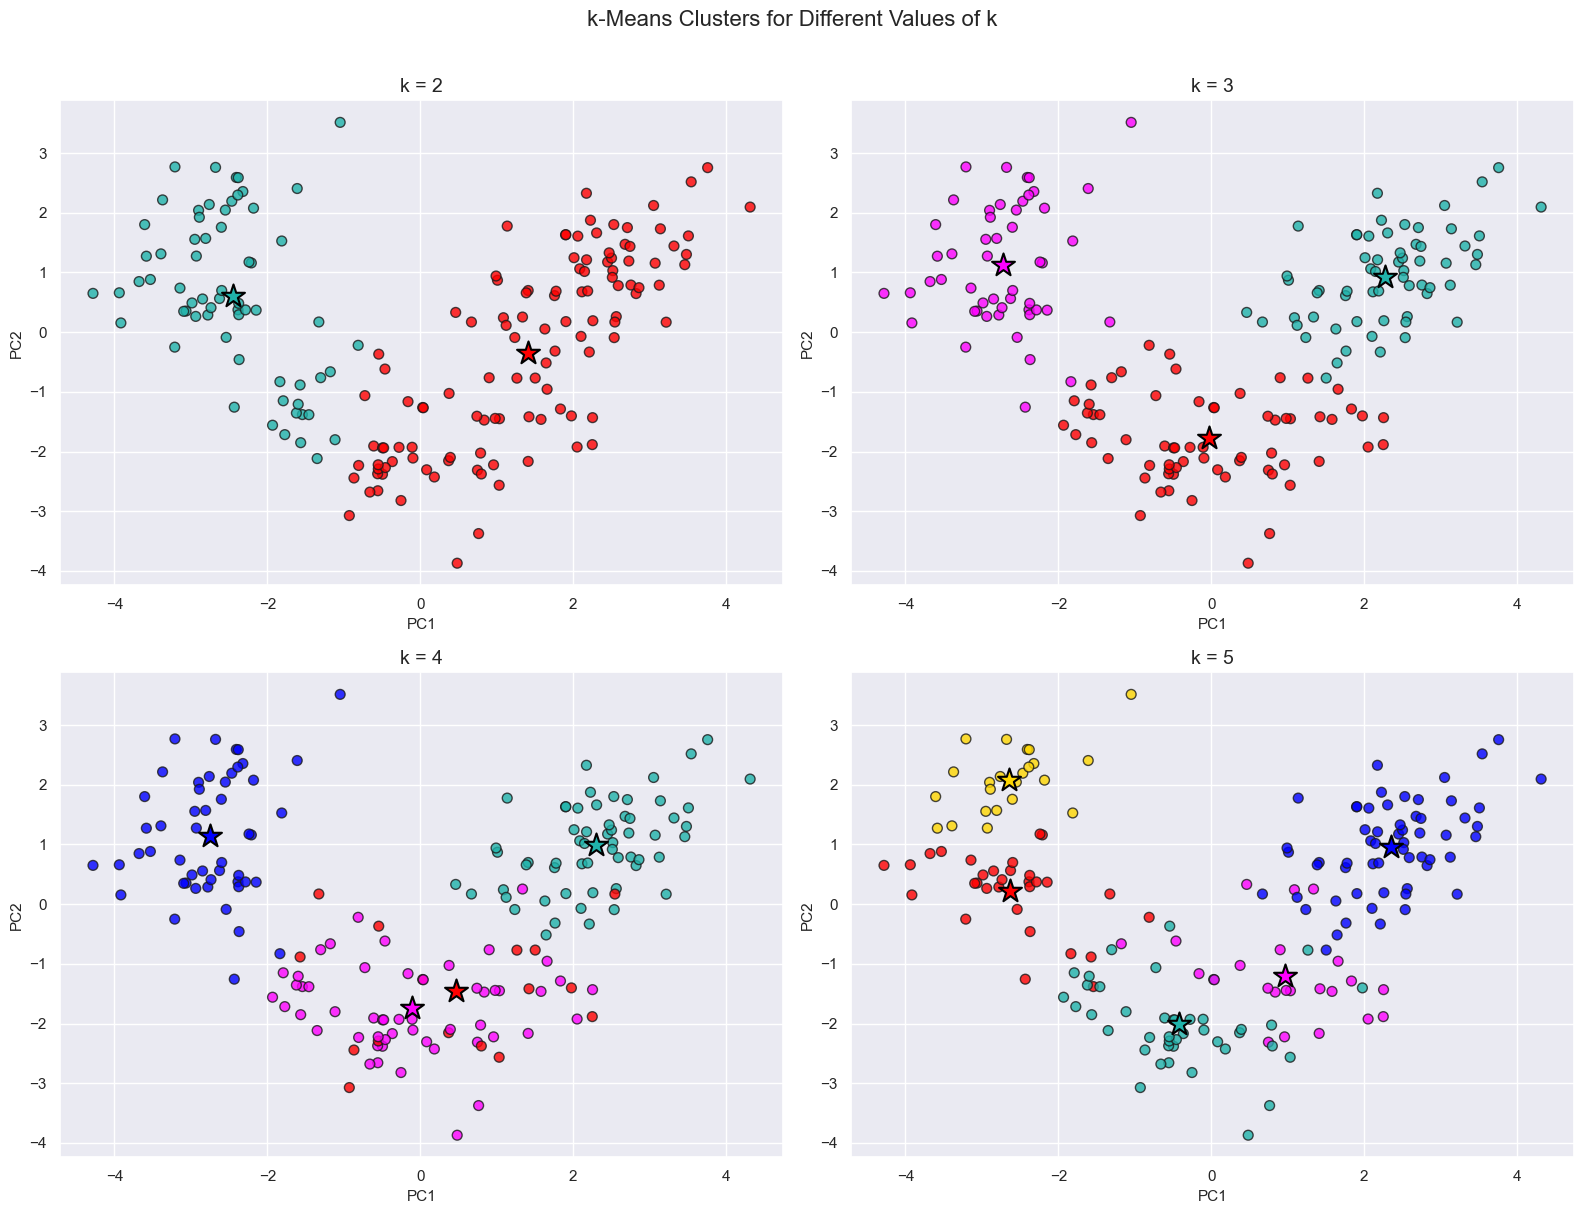

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, k in zip(axes.flatten(), [2, 3, 4, 5]):
    centers_k  = k_means_clustering(X, k=k, max_iter=100, random_state=42)
    labels_k   = assign_clusters(X, centers_k)
    colors_k   = [cluster_colors(l) for l in labels_k]
    centers_2d_k = pca.transform(np.array(centers_k))

    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors_k,
               edgecolors="k", s=50, alpha=0.8)
    for j, (cx, cy) in enumerate(centers_2d_k):
        ax.scatter(cx, cy, color=cluster_colors(j),
                   s=300, marker="*", edgecolors="black", linewidths=1.5)
    ax.set_title(f"k = {k}", fontsize=14)
    ax.set_xlabel("PC1", fontsize=11)
    ax.set_ylabel("PC2", fontsize=11)

plt.suptitle("k-Means Clusters for Different Values of k", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---

## 11. From-Scratch vs. sklearn KMeans

As a final sanity check we compare our hand-built implementation against `sklearn`'s optimised `KMeans` on the same data.

---

In [19]:
# sklearn KMeans
skl_km = SklearnKMeans(n_clusters=3, n_init=10, random_state=42)
skl_km.fit(X)
skl_labels = skl_km.labels_

skl_ari = adjusted_rand_score(y_true, skl_labels)
skl_sil = silhouette_score(X, skl_labels)

print("=" * 40)
print(f"{'Metric':<22} {'Scratch':>8} {'sklearn':>8}")
print("=" * 40)
print(f"{'ARI':<22} {ari:>8.4f} {skl_ari:>8.4f}")
print(f"{'Silhouette Score':<22} {sil_score:>8.4f} {skl_sil:>8.4f}")
print("=" * 40)

Metric                  Scratch  sklearn
ARI                      0.8975   0.8975
Silhouette Score         0.2849   0.2849


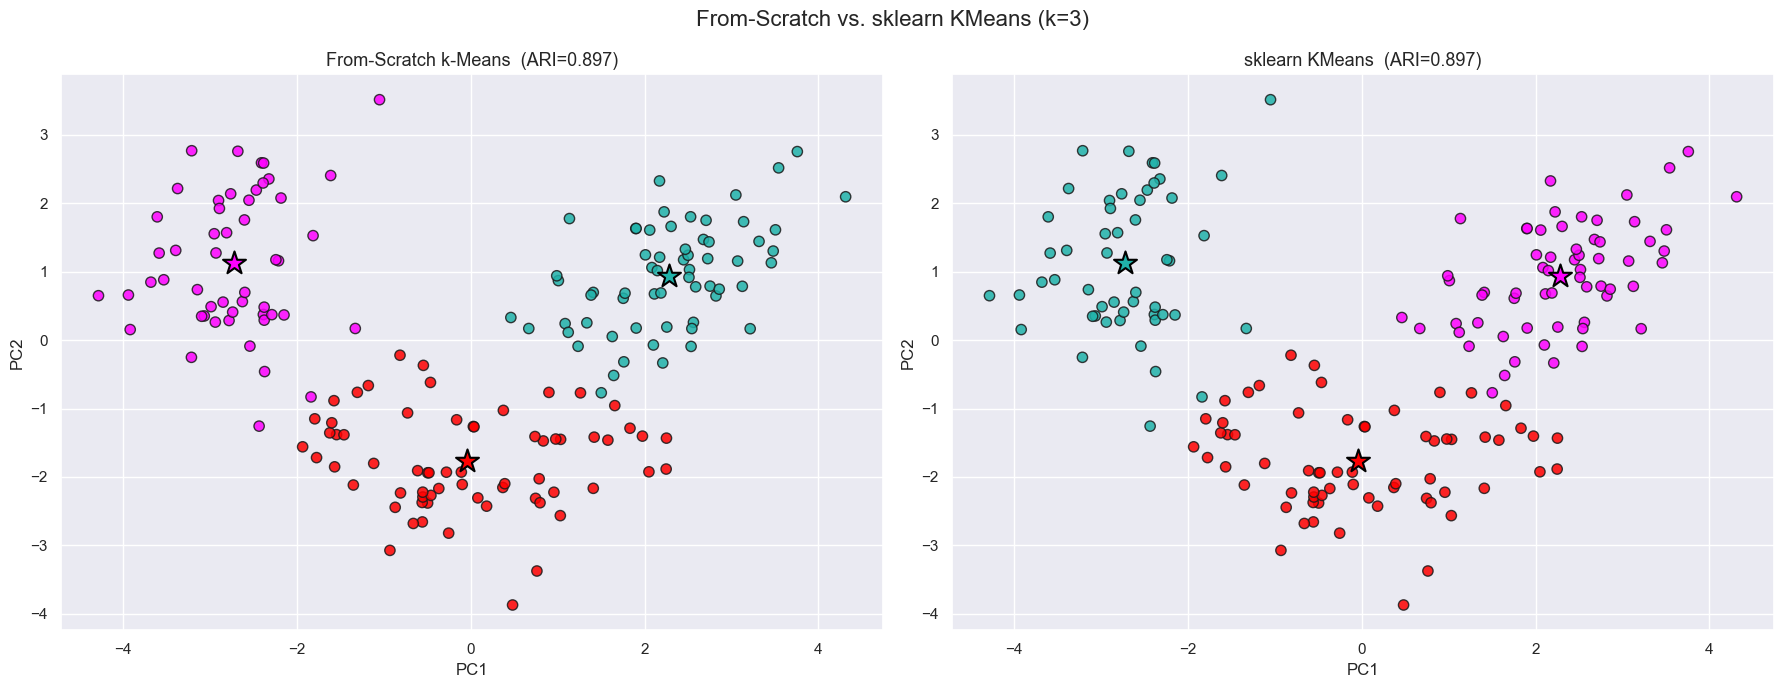

In [20]:
# Side-by-side final comparison
skl_colors = [cluster_colors(l) for l in skl_labels]
skl_centers_2d = pca.transform(skl_km.cluster_centers_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# From-scratch
ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=final_colors,
            edgecolors="k", s=55, alpha=0.85)
for j, (cx, cy) in enumerate(centers_2d_final):
    ax1.scatter(cx, cy, color=cluster_colors(j), s=300,
                marker="*", edgecolors="black", linewidths=1.5)
ax1.set_title(f"From-Scratch k-Means  (ARI={ari:.3f})", fontsize=13)
ax1.set_xlabel("PC1", fontsize=12); ax1.set_ylabel("PC2", fontsize=12)

# sklearn
ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=skl_colors,
            edgecolors="k", s=55, alpha=0.85)
for j, (cx, cy) in enumerate(skl_centers_2d):
    ax2.scatter(cx, cy, color=cluster_colors(j), s=300,
                marker="*", edgecolors="black", linewidths=1.5)
ax2.set_title(f"sklearn KMeans  (ARI={skl_ari:.3f})", fontsize=13)
ax2.set_xlabel("PC1", fontsize=12); ax2.set_ylabel("PC2", fontsize=12)

plt.suptitle("From-Scratch vs. sklearn KMeans (k=3)", fontsize=16)
plt.tight_layout()
plt.show()